# **EfficientNet Pre-trained Binary Model with Transformed Input**

In this notebook we test a pre-trained EfficientNet model to predict Animal vs Non-animal. <br>
For this, transformed/pre-processed images were used, which were generated with the help of the notebook `cleaner_routine.ipynb`. <br>

If you have ran any other model before, do not forget to reset the `input_image_directory` by running 'reset input' in the terminal.

## Libraries

In [1]:
import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

In [2]:
# Libraries
import pandas as pd

from deep.constants import ROOT, METADATA_FILE, SEEDS, SCORES
from deep.modelling.model_runs import run_binary_model
from deep.modelling.model_specifications import efficient_net

2025-04-28 21:01:54.704974: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-28 21:01:54.792382: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-28 21:01:54.818417: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-28 21:01:54.826130: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-28 21:01:54.908008: I tensorflow/core/platform/cpu_feature_guar

In [3]:
# Setting options
pd.set_option('display.max_rows', None)

## Data Loading

In [4]:
# Load the metadata
data = pd.read_csv(METADATA_FILE)

# Drop unnecessary columns for this problem
data.drop(columns=['phylum', 'family'], inplace=True)

## Data Preprocessing

In [5]:
# Define seeds and path
binary_baseline_path = f"{SCORES}/binary_scores.json"

### Clean Images

In [ ]:
# Create transformed images
notebook_path = f'"{ROOT}/notebooks/preprocess_routine/cleaner_routine.ipynb"'
%run $notebook_path

### Resize Images

In [ ]:
# Resize images
notebook_path = f'"{ROOT}/notebooks/preprocess_routine/resize_routine.ipynb"'
%run $notebook_path

## Data Modelling

### Raw Model

I0000 00:00:1745870518.104583    3909 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745870518.269379    3909 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745870518.269595    3909 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745870518.270950    3909 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Loaded baseline score: 0.9291174411773682
Found 8148 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


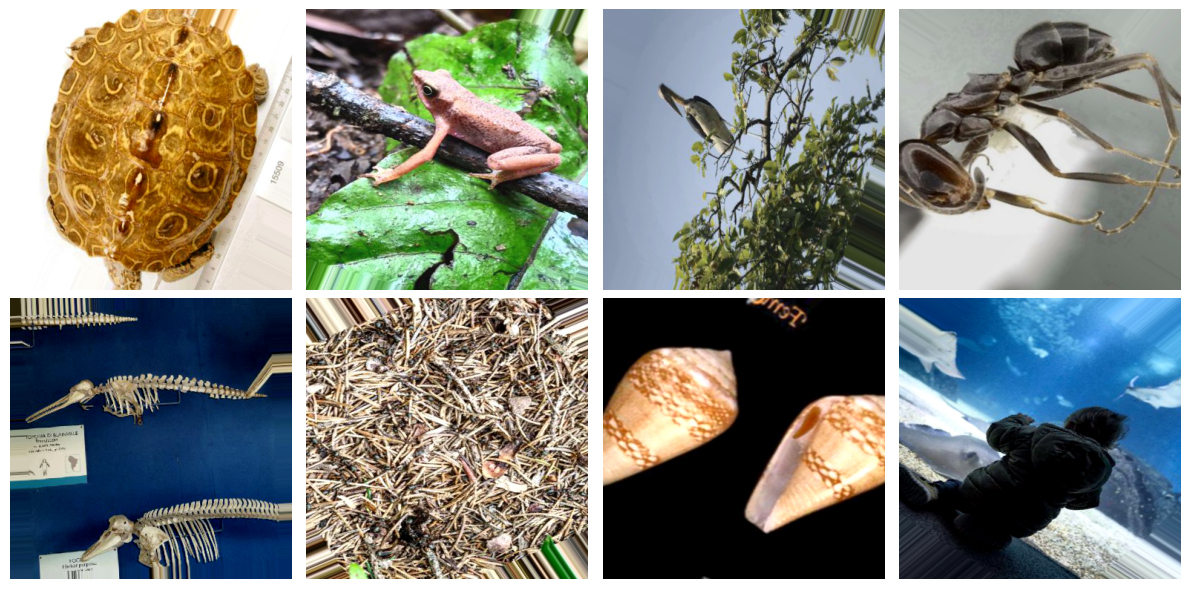

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1745870539.749355    6128 service.cc:146] XLA service 0x72ebb0097780 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745870539.749381    6128 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce MX350, Compute Capability 6.1
2025-04-28 21:02:20.518380: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-28 21:02:22.952371: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90100
2025-04-28 21:02:30.017039: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:310] gpu_async_0 cuMemAllocAsync failed to allocate 1437078016 bytes: CUDA error: out of memory (CUDA_ERROR_OUT_OF_MEMORY)
 Reported by CUDA: Free memory/Total memory: 249167872/2091253760
2025-04-28 21:02:30.017078: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc

254/255 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8721 - auc: 0.5148 - loss: 0.4624 - precision: 0.9244 - recall: 0.9378

2025-04-28 21:08:43.136215: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:310] gpu_async_0 cuMemAllocAsync failed to allocate 2096510464 bytes: CUDA error: out of memory (CUDA_ERROR_OUT_OF_MEMORY)
 Reported by CUDA: Free memory/Total memory: 242876416/2091253760
2025-04-28 21:08:43.136250: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:315] Stats: Limit:                      1806303232
InUse:                      1075377652
MaxInUse:                   1931878220
NumAllocs:                        7840
MaxAllocSize:               1621712896
Reserved:                            0
PeakReserved:                        0
LargestFreeBlock:                    0

2025-04-28 21:08:43.136316: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:64] Histogram of current allocation: (allocation_size_in_bytes, nb_allocation_of_that_sizes), ...;
2025-04-28 21:08:43.136324: E external/local_xla/xla/stream_executor/

255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8722 - auc: 0.5148 - loss: 0.4619 - precision: 0.9245 - recall: 0.9380

2025-04-28 21:10:02.755264: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:310] gpu_async_0 cuMemAllocAsync failed to allocate 1411715584 bytes: CUDA error: out of memory (CUDA_ERROR_OUT_OF_MEMORY)
 Reported by CUDA: Free memory/Total memory: 242876416/2091253760
2025-04-28 21:10:02.755310: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:315] Stats: Limit:                      1806303232
InUse:                       623107644
MaxInUse:                   1931878220
NumAllocs:                        9157
MaxAllocSize:               1621712896
Reserved:                            0
PeakReserved:                        0
LargestFreeBlock:                    0

2025-04-28 21:10:02.755388: E external/local_xla/xla/stream_executor/gpu/gpu_cudamallocasync_allocator.cc:64] Histogram of current allocation: (allocation_size_in_bytes, nb_allocation_of_that_sizes), ...;
2025-04-28 21:10:02.755396: E external/local_xla/xla/stream_executor/

255/255 ━━━━━━━━━━━━━━━━━━━━ 505s 2s/step - accuracy: 0.8724 - auc: 0.5149 - loss: 0.4614 - precision: 0.9245 - recall: 0.9382 - val_accuracy: 0.9291 - val_auc: 0.6246 - val_loss: 0.2532 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 374s 1s/step - accuracy: 0.9286 - auc: 0.5818 - loss: 0.2545 - precision: 0.9286 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc: 0.6085 - val_loss: 0.2841 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.9258 - auc: 0.6049 - loss: 0.2586 - precision: 0.9258 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc: 0.6334 - val_loss: 0.2500 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 396s 2s/step - accuracy: 0.9328 - auc: 0.6042 - loss: 0.2436 - precision: 0.9328 - recall: 0.9999 - val_accuracy: 0.9291 - val_auc: 0.6361 - val_loss: 0.2509 - val_precis

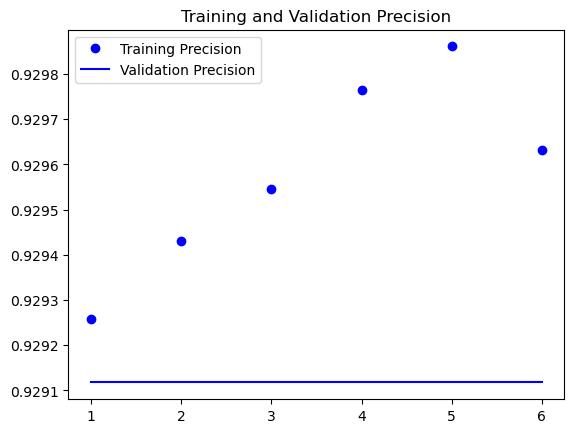

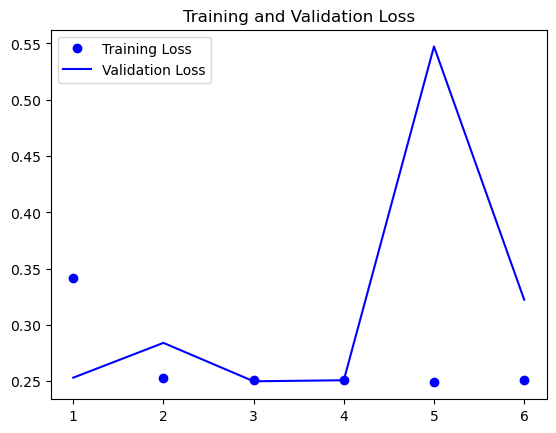

Current model not better than baseline


In [6]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net(
        regularizer=False
        ,dropout=False
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='transformed'
    ,model_name='efficientnetb4'
)

This model with the transformed images proved to not yield better precision results than with the original images.

### Model with Regularization

In this section we add L2 regularization to our model and test if it improves the model

Loaded baseline score: 0.9291174411773682
Found 8148 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


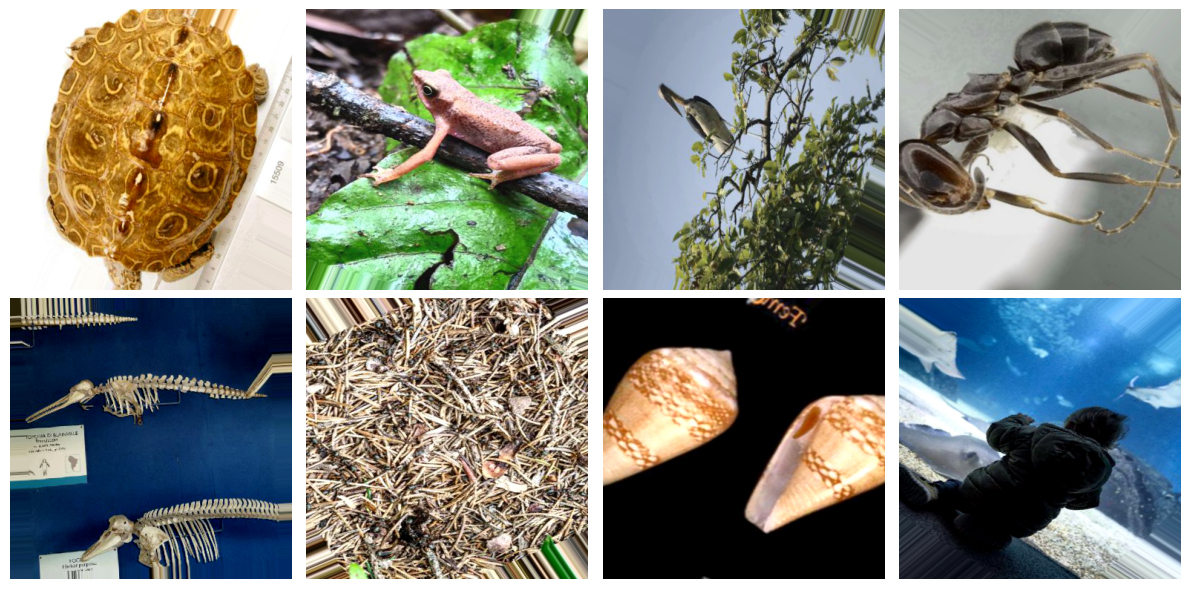

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 470s 2s/step - accuracy: 0.8135 - auc_1: 0.5332 - loss: 0.5751 - precision: 0.9283 - recall: 0.8669 - val_accuracy: 0.9013 - val_auc_1: 0.6212 - val_loss: 0.6000 - val_precision: 0.9364 - val_recall: 0.9589 - learning_rate: 0.0010
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 397s 2s/step - accuracy: 0.9335 - auc_1: 0.5582 - loss: 0.2504 - precision: 0.9336 - recall: 0.9999 - val_accuracy: 0.9291 - val_auc_1: 0.6153 - val_loss: 0.2635 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 404s 2s/step - accuracy: 0.9287 - auc_1: 0.5672 - loss: 0.2581 - precision: 0.9287 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc_1: 0.6095 - val_loss: 0.2897 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9336 - auc_1: 0.5565 - loss: 0.2460 - precision: 0.9336 - recall: 1.0000
Epoch 4: ReduceLROnPlateau reducing learning rate

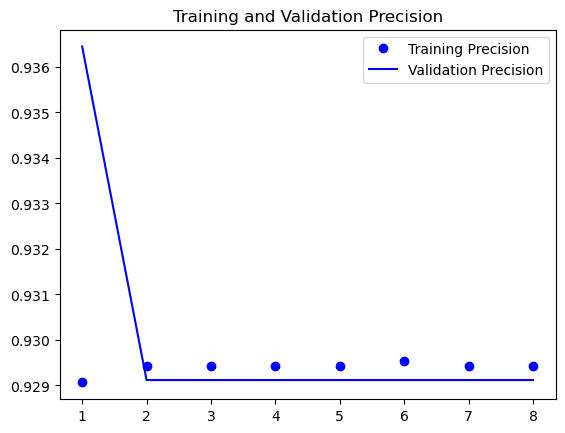

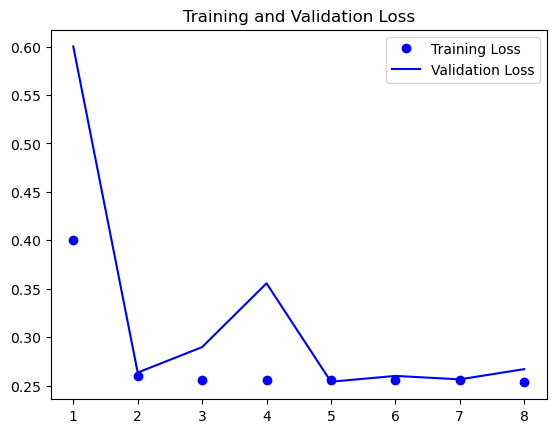

Current model not better than baseline


In [7]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net(
        regularizer=True
        ,dropout=False
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='transformed'
    ,model_name='efficientnetb4'
)

Regularization did not improve the model.

### Model with Dropout

In this section we add a dropout layer to the model and test if it improves the results.

Loaded baseline score: 0.9291174411773682
Found 8148 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


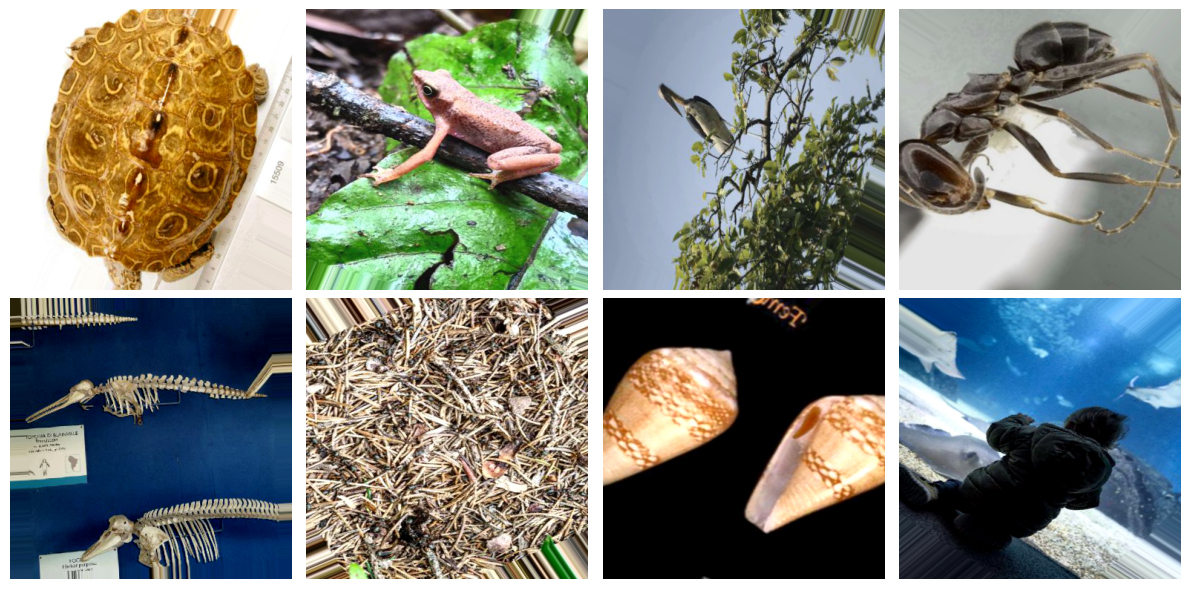

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 470s 2s/step - accuracy: 0.7826 - auc_2: 0.5205 - loss: 0.5220 - precision: 0.9318 - recall: 0.8270 - val_accuracy: 0.9291 - val_auc_2: 0.6191 - val_loss: 0.2619 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 403s 2s/step - accuracy: 0.9290 - auc_2: 0.5275 - loss: 0.2668 - precision: 0.9297 - recall: 0.9992 - val_accuracy: 0.9291 - val_auc_2: 0.5488 - val_loss: 0.2561 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 407s 2s/step - accuracy: 0.9309 - auc_2: 0.5062 - loss: 0.2595 - precision: 0.9309 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc_2: 0.5886 - val_loss: 0.2842 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9289 - auc_2: 0.5098 - loss: 0.2597 - precision: 0.9289 - recall: 1.0000
Epoch 4: ReduceLROnPlateau reducing learning rate

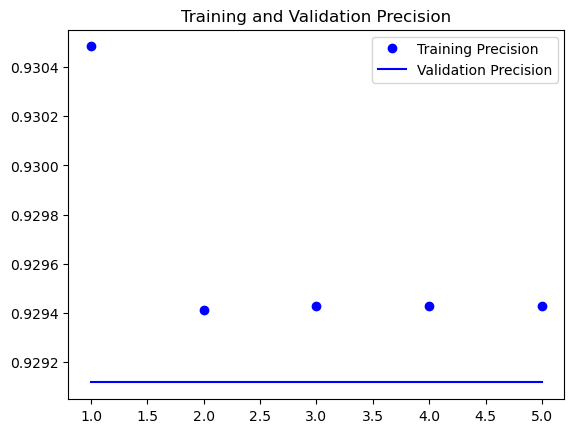

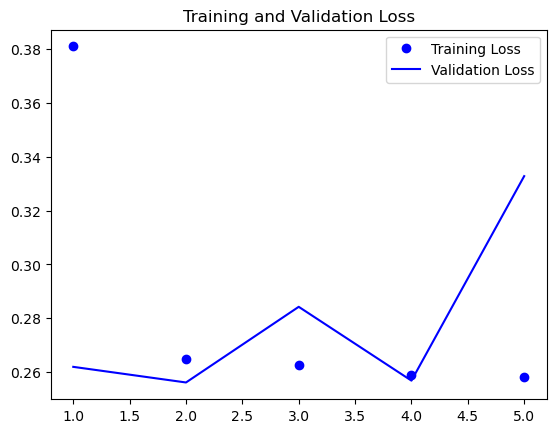

Current model not better than baseline


In [8]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net(
        regularizer=False
        ,dropout=True
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='transformed'
    ,model_name='efficientnetb4'
)

The dropout layer did not improve the model.

### Regularizer and Dropout

Since both options yield the same result, we try a model with both and see if it improves.

Loaded baseline score: 0.9291174411773682
Found 8148 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


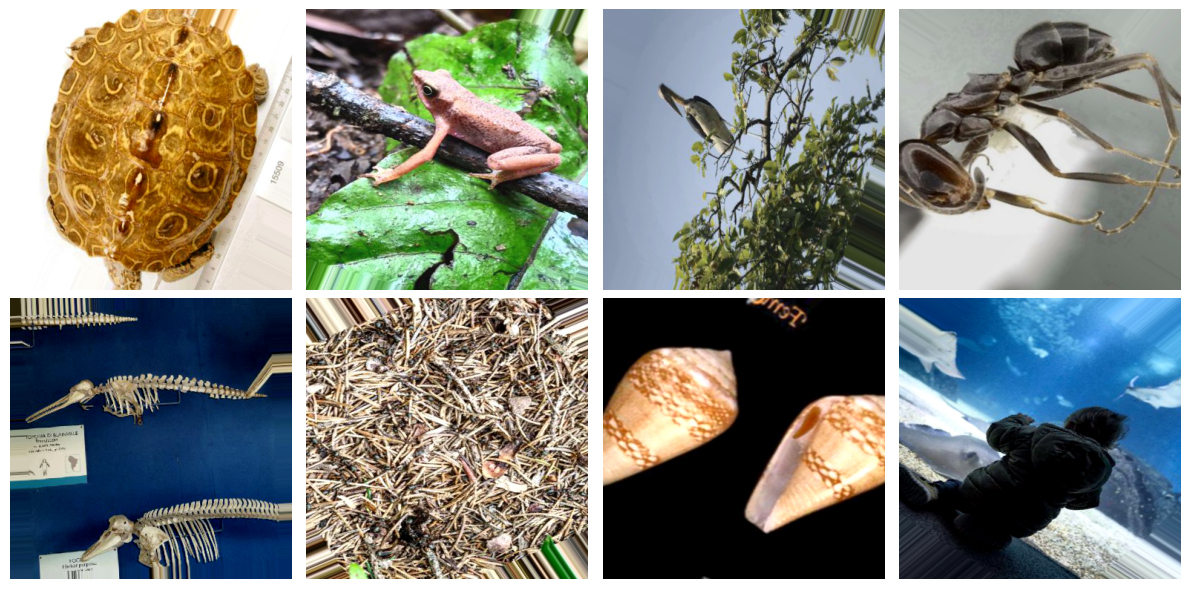

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 483s 2s/step - accuracy: 0.7962 - auc_3: 0.5020 - loss: 0.5745 - precision: 0.9251 - recall: 0.8492 - val_accuracy: 0.9291 - val_auc_3: 0.5900 - val_loss: 0.2832 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 421s 2s/step - accuracy: 0.9353 - auc_3: 0.5006 - loss: 0.2548 - precision: 0.9353 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc_3: 0.5194 - val_loss: 0.2771 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 426s 2s/step - accuracy: 0.9271 - auc_3: 0.5268 - loss: 0.2668 - precision: 0.9272 - recall: 0.9999 - val_accuracy: 0.9291 - val_auc_3: 0.5000 - val_loss: 0.2596 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
255/255 ━━━━━━━━━━━━━━━━━━━━ 426s 2s/step - accuracy: 0.9262 - auc_3: 0.5053 - loss: 0.2668 - precision: 0.9262 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc_3: 0.4818 - va

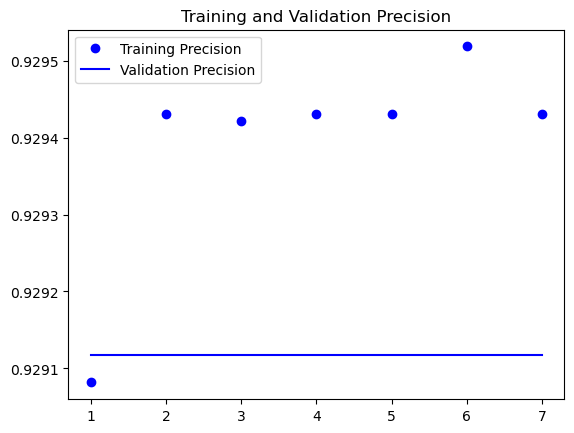

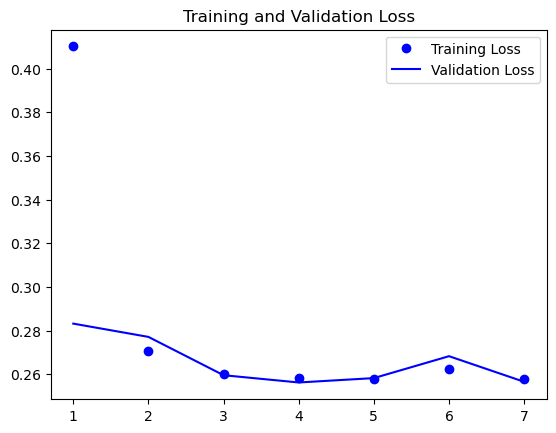

Current model not better than baseline


In [9]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEEDS[0]
    ,model=efficient_net(
        regularizer=True
        ,dropout=True
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='transformed'
    ,model_name='efficientnetb4'
)

Having a model with both options did not improve the model

Now, we will attempt to fix the class imbalance based on the transformed images and recheck the model.